# GLM-HMM state-count comparison: does LDA1 relate to how many states a mouse's behavior needs?

This notebook summarizes the K=2 vs K=3 GLM-HMM model-comparison work (`loso_k2_k3_sweep.py`, `k3_state_interpretation.py`) run on the 54 LDA-matched mice with >=3 sessions (242 sessions total). Everything here reads from the CSVs those scripts already produced in `k2_k3_pilot/` - no refitting happens in this notebook.

Background: the pilot in `compare_k2_k3_pilot.py` first tested this in-sample on 4 sessions (2 low-LDA1, 2 high-LDA1); this notebook covers the follow-up full, held-out (leave-one-session-out) sweep across the whole matched population, plus what the fitted states actually represent.

In [25]:
"""
SHARED FIGURE STYLE -- run this cell first (see paper_style.py for the conventions).
Panel sizes and type come from the active mode; the correlation panels below are
ps.corr_panel, so their marker size, their significance-gated fit and the way r is
reported are the same as in load_states and the LDA notebooks.
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


sys.path.insert(0, str(_find_paper_style()))
import paper_style as ps

ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


def small(f=0.85):
    return plt.rcParams['font.size'] * f


def panels(nrow=1, ncol=1, w=1.0, h=1.0, **kw):
    """subplots sized in units of the current mode's 'single' panel."""
    pw, ph = ps.FIG['single']
    return plt.subplots(nrow, ncol, figsize=(pw * w * ncol, ph * h * nrow), **kw)


OUT_DIR = 'k2_k3_pilot'

loso_wide = pd.read_csv(f'{OUT_DIR}/loso_k2_k3_wide.csv')
weights = pd.read_csv(f'{OUT_DIR}/k3_state_interpretation_weights.csv')
occupancy = pd.read_csv(f'{OUT_DIR}/k3_state_interpretation_occupancy.csv')

print(f"LOSO sweep: {loso_wide['mouse_name'].nunique()} mice, {len(loso_wide)} held-out sessions")
print(f"State interpretation: {weights['mouse_name'].nunique()} mice")

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi
LOSO sweep: 54 mice, 242 held-out sessions
State interpretation: 54 mice


## 1. Does K=3 improve held-out prediction overall?

For every session, K=2 and K=3 were each fit by pooling that mouse's *other* sessions (leave-one-session-out), then scored on held-out log-likelihood for the excluded session - genuinely out-of-sample, not the mechanically-biased in-sample comparison from the initial 4-session pilot.

count    242.000000
mean       0.015522
std        0.020497
min       -0.029223
25%        0.001890
50%        0.011364
75%        0.023360
max        0.131379
Name: gain_K3_over_K2, dtype: float64

Fraction of held-out sessions where K=3 beats K=2: 81.8%
wrote figures/kstate_holdout_gain_poster_08-09-2026.png, figures/kstate_holdout_gain_poster_08-09-2026.svg


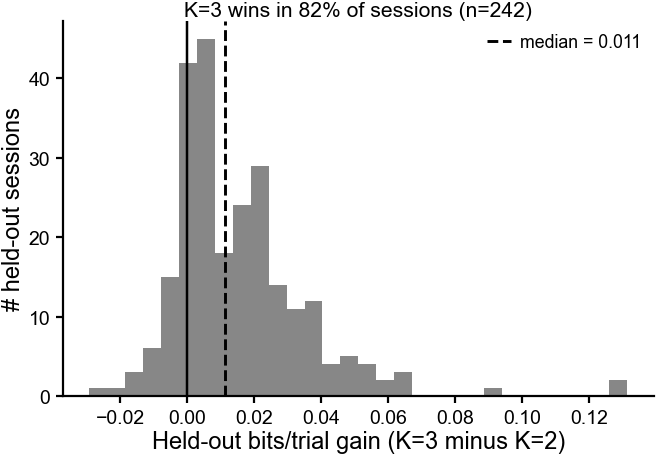

In [26]:
gain = loso_wide['gain_K3_over_K2']
frac_improved = (gain > 0).mean()

print(gain.describe())
print(f"\nFraction of held-out sessions where K=3 beats K=2: {frac_improved:.1%}")

# one distribution, so ps.NEUTRAL: colour would imply a grouping that isn't here
ps.reapply()
fig, ax = ps.figure('single')
ax.hist(gain, bins=30, color=ps.NEUTRAL, alpha=0.9)
lw = plt.rcParams['lines.linewidth']
ax.axvline(0, color='k', lw=lw * 0.6)
ax.axvline(gain.median(), color='k', ls='--', lw=lw * 0.7,
           label=f'median = {gain.median():.3f}')
ax.set_xlabel('Held-out bits/trial gain (K=3 minus K=2)')
ax.set_ylabel('# held-out sessions')
ax.set_title(f'K=3 wins in {frac_improved:.0%} of sessions (n={len(gain)})', fontsize=small(0.95))
ax.legend(fontsize=small(0.8))
fig.tight_layout()
ps.savefig(fig, 'kstate_holdout_gain', svg=True)
plt.show()

## 2. Is the K=3 benefit related to LDA1?

Session-level (n=242, pseudo-replicated across each mouse's sessions) and mouse-averaged (n=54, the more trustworthy test).

Session-level (n=242): Pearson r=-0.12 (p=0.058), Spearman r=-0.16 (p=0.015)
Mouse-averaged (n=54): Pearson r=-0.21 (p=0.119), Spearman r=-0.25 (p=0.064)
wrote figures/kstate_gain_vs_lda_poster_08-09-2026.png, figures/kstate_gain_vs_lda_poster_08-09-2026.svg


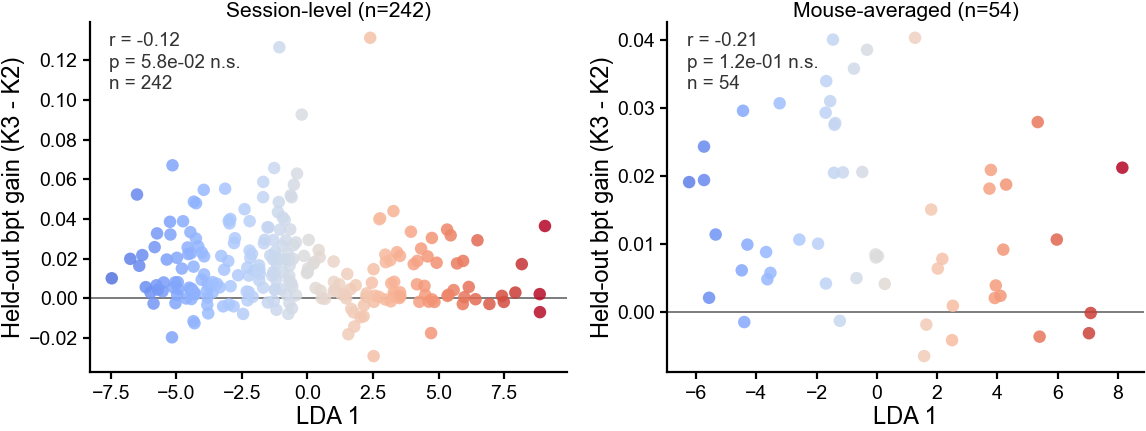

Modest negative trend (lower LDA1 -> bigger K=3 gain), direction matches the
original hypothesis, but only the session-level Spearman clears p<0.05 - the
mouse-averaged version (the more trustworthy test, avoids pseudo-replication) is
only borderline (p=0.06-0.12). Suggestive, not confirmed.
NOTE the panels now draw their fit ONLY where the correlation is significant, so a
panel with points and no line is the null result, not a missing line.


In [27]:
mouse_agg_gain = loso_wide.groupby('mouse_name').agg(
    lda1_mean=('lda_1', 'mean'), gain_mean=('gain_K3_over_K2', 'mean')
).reset_index()

ps.reapply()
fig, axes = panels(1, 2, w=0.85, h=0.95)

for ax, x, y, title in [
    (axes[0], loso_wide['lda_1'], loso_wide['gain_K3_over_K2'], f'Session-level (n={len(loso_wide)})'),
    (axes[1], mouse_agg_gain['lda1_mean'], mouse_agg_gain['gain_mean'], f'Mouse-averaged (n={len(mouse_agg_gain)})'),
]:
    st = ps.corr_panel(ax, x, y, xlabel='LDA 1', ylabel='Held-out bpt gain (K3 - K2)')
    ps.zero_line(ax)
    ax.set_title(title, fontsize=small(0.95))
    print(f"{title}: Pearson r={st['r_pearson']:.2f} (p={st['p_pearson']:.3f}), "
          f"Spearman r={st['r_spearman']:.2f} (p={st['p_spearman']:.3f})")

fig.tight_layout()
ps.savefig(fig, 'kstate_gain_vs_lda', svg=True)
plt.show()

print("Modest negative trend (lower LDA1 -> bigger K=3 gain), direction matches the\n"
      "original hypothesis, but only the session-level Spearman clears p<0.05 - the\n"
      "mouse-averaged version (the more trustworthy test, avoids pseudo-replication) is\n"
      "only borderline (p=0.06-0.12). Suggestive, not confirmed.\n"
      "NOTE the panels now draw their fit ONLY where the correlation is significant, so a\n"
      "panel with points and no line is the null result, not a missing line.")

## 3. What do the 3 states actually represent?

The "engaged" state, per mouse, is identified as whichever of the 3 fitted states has the largest-magnitude stimulus weight (steepest psychometric slope) - not a fixed index, since EM label-switching means state order isn't guaranteed to match across mice.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_62108/3019416334.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  opp_frac = k3_weights.groupby('mouse_name').apply(opposite_bias).mean()


wrote figures/kstate_weight_separation_poster_08-09-2026.png, figures/kstate_weight_separation_poster_08-09-2026.svg


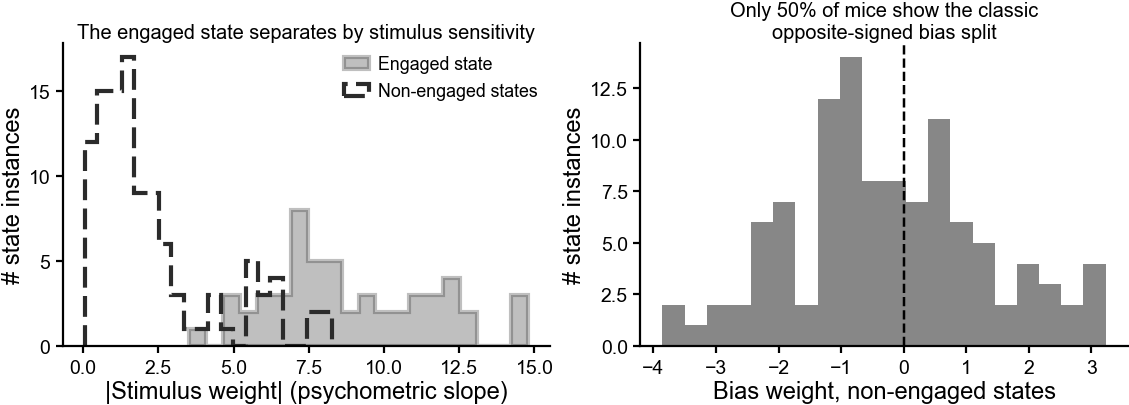

Engaged state mean |stim| weight: 8.86
Non-engaged states mean |stim| weight: 2.28

Fraction of mice where the 2 non-engaged states have opposite-signed bias (i.e. cleanly split into 'biased-left'/'biased-right'): 0.50
In the other half, the two non-engaged states differ some other way (degree of
bias, or history-dependence via prev_choice/wsls) rather than mirror-image bias
direction - so there isn't one universal 3-state template across the population.


In [28]:
k3_weights = weights[weights['K'] == 3]
engaged = k3_weights[k3_weights['is_engaged']]
non_engaged = k3_weights[~k3_weights['is_engaged']]

ps.reapply()
fig, axes = panels(1, 2, w=0.85, h=0.9)

# engaged vs non-engaged: one ink, told apart by FORM (filled step vs dashed outline),
# the same way load_states draws the two states
axes[0].hist(engaged['stim'].abs(), bins=20,
             **ps.state_kw('engaged', 'hist', label='Engaged state'))
axes[0].hist(non_engaged['stim'].abs(), bins=20,
             **ps.state_kw('disengaged', 'hist', label='Non-engaged states'))
axes[0].set_xlabel('|Stimulus weight| (psychometric slope)')
axes[0].set_ylabel('# state instances')
axes[0].set_title('The engaged state separates by stimulus sensitivity', fontsize=small(0.9))
axes[0].legend(fontsize=small(0.8))


def opposite_bias(g):
    ne = g[~g['is_engaged']]
    if len(ne) != 2:
        return np.nan
    b = ne['bias'].values
    return (b[0] * b[1]) < 0


opp_frac = k3_weights.groupby('mouse_name').apply(opposite_bias).mean()

axes[1].hist(non_engaged['bias'], bins=20, color=ps.NEUTRAL, alpha=0.9)
axes[1].axvline(0, color='k', ls='--', lw=plt.rcParams['lines.linewidth'] * 0.6)
axes[1].set_xlabel('Bias weight, non-engaged states')
axes[1].set_ylabel('# state instances')
axes[1].set_title(f"Only {opp_frac:.0%} of mice show the classic\nopposite-signed bias split",
                  fontsize=small(0.9))

fig.tight_layout()
ps.savefig(fig, 'kstate_weight_separation', svg=True)
plt.show()

print(f"Engaged state mean |stim| weight: {engaged['stim'].abs().mean():.2f}")
print(f"Non-engaged states mean |stim| weight: {non_engaged['stim'].abs().mean():.2f}")
print(f"\nFraction of mice where the 2 non-engaged states have opposite-signed bias"
      f" (i.e. cleanly split into 'biased-left'/'biased-right'): {opp_frac:.2f}")
print("In the other half, the two non-engaged states differ some other way (degree of\n"
      "bias, or history-dependence via prev_choice/wsls) rather than mirror-image bias\n"
      "direction - so there isn't one universal 3-state template across the population.")

## 4. Does hard engaged-occupancy correlate more cleanly with LDA1 under K=3?

This directly tests: "maybe all mice benefit from a 3rd state, and once it's absorbed the extra structure, engagement (in hard trial-count terms) becomes easier to detect as a function of LDA1." Compares K=2 and K=3 side by side, session-level and mouse-averaged.

K=2, session-level (n=242): Pearson r=0.05 (p=0.445), Spearman r=0.11 (p=0.102)
K=2, mouse-averaged (n=54): Pearson r=0.10 (p=0.487), Spearman r=0.09 (p=0.519)
K=3, session-level (n=242): Pearson r=-0.01 (p=0.837), Spearman r=0.05 (p=0.462)
K=3, mouse-averaged (n=54): Pearson r=-0.00 (p=0.981), Spearman r=0.07 (p=0.622)
wrote figures/kstate_occupancy_vs_lda_poster_08-09-2026.png, figures/kstate_occupancy_vs_lda_poster_08-09-2026.svg


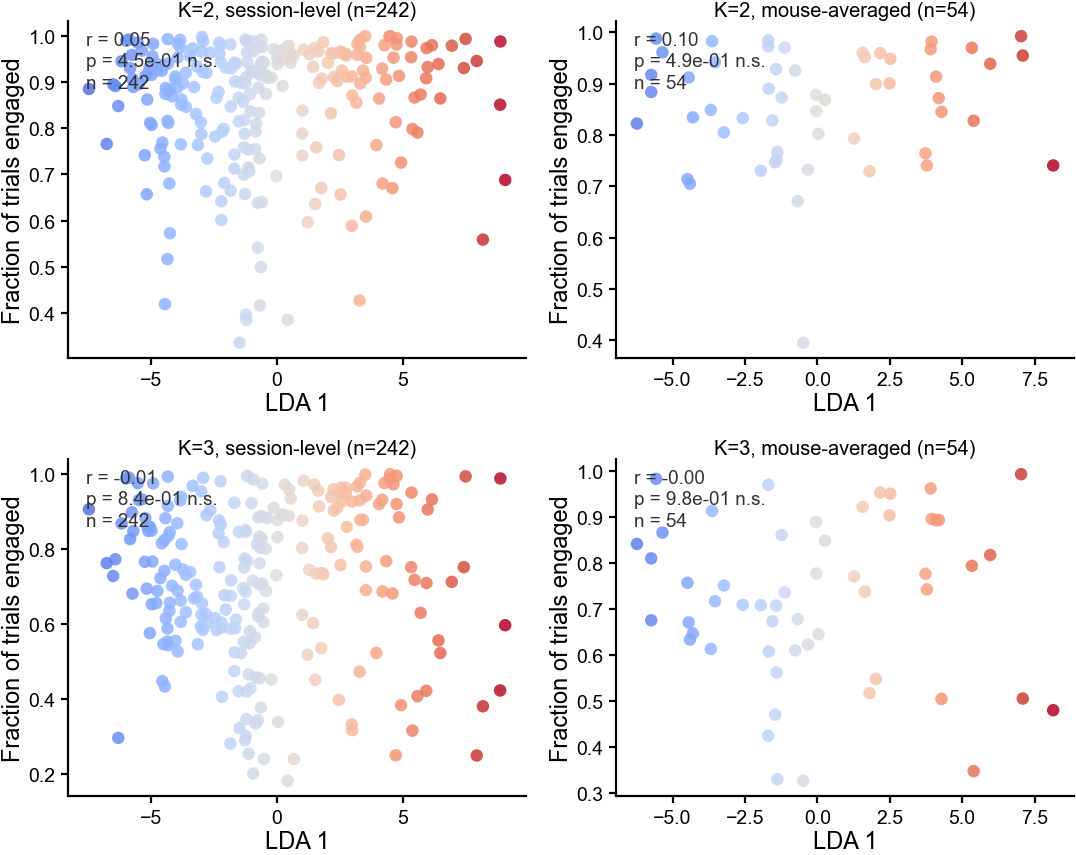

Both K=2 and K=3 give essentially null correlations (all p >> 0.05) - so all four
panels show points and no fitted line, which is the convention's way of saying null.
If anything K=3 is flatter, not clearer. Hard time-in-engaged-state just isn't where
the LDA1 signal lives, at either K - consistent with the earlier finding
(load_states.ipynb) that the real, robust LDA1 signal is in SWITCHING DYNAMICS/
stickiness (dwell-time stability), not in overall occupancy fraction. This replicates
that conclusion under a genuinely different, better-fitting model.


In [29]:
ps.reapply()
fig, axes = panels(2, 2, w=0.8, h=0.9)

for row, K in enumerate((2, 3)):
    sub = occupancy[occupancy['K'] == K]
    mouse_agg = sub.groupby('mouse_name').agg(
        lda1_mean=('lda_1', 'mean'), frac_engaged_mean=('frac_engaged', 'mean')
    ).reset_index()

    for col, (x, y, title) in enumerate([
        (sub['lda_1'], sub['frac_engaged'], f'K={K}, session-level (n={len(sub)})'),
        (mouse_agg['lda1_mean'], mouse_agg['frac_engaged_mean'], f'K={K}, mouse-averaged (n={len(mouse_agg)})'),
    ]):
        ax = axes[row, col]
        st = ps.corr_panel(ax, x, y, xlabel='LDA 1', ylabel='Fraction of trials engaged')
        ax.set_title(title, fontsize=small(0.9))
        print(f"{title}: Pearson r={st['r_pearson']:.2f} (p={st['p_pearson']:.3f}), "
              f"Spearman r={st['r_spearman']:.2f} (p={st['p_spearman']:.3f})")

fig.tight_layout()
ps.savefig(fig, 'kstate_occupancy_vs_lda', svg=True)
plt.show()

print("Both K=2 and K=3 give essentially null correlations (all p >> 0.05) - so all four\n"
      "panels show points and no fitted line, which is the convention's way of saying null.\n"
      "If anything K=3 is flatter, not clearer. Hard time-in-engaged-state just isn't where\n"
      "the LDA1 signal lives, at either K - consistent with the earlier finding\n"
      "(load_states.ipynb) that the real, robust LDA1 signal is in SWITCHING DYNAMICS/\n"
      "stickiness (dwell-time stability), not in overall occupancy fraction. This replicates\n"
      "that conclusion under a genuinely different, better-fitting model.")

## 5. Does the pattern continue at K=4?

Same LOSO design extended to K=4 (3 random-restart fits per fold, since there's no literature-derived reference init beyond K=3 - see `fit_k_general.py`). This checks two things: (a) do returns from adding states keep growing, shrink, or plateau, and (b) does the LDA1 relationship strengthen, weaken, or stay the same as model capacity grows.

=== Marginal returns from adding states (held-out bpt gain) ===
K3-K2: mean=0.0155, median=0.0114, frac_positive=81.8%
K4-K3: mean=0.0053, median=0.0016, frac_positive=59.9%
K4-K2: mean=0.0209, median=0.0167, frac_positive=82.6%
K4-K3, session-level (n=242): Pearson r=-0.11 (p=0.096), Spearman r=-0.17 (p=0.009)
K4-K3, mouse-averaged (n=54): Pearson r=-0.15 (p=0.291), Spearman r=-0.14 (p=0.306)
K4-K2 (total), session-level (n=242): Pearson r=-0.16 (p=0.011), Spearman r=-0.21 (p=0.001)
K4-K2 (total), mouse-averaged (n=54): Pearson r=-0.23 (p=0.091), Spearman r=-0.28 (p=0.039)
wrote figures/kstate_k4_gain_vs_lda_poster_08-09-2026.png, figures/kstate_k4_gain_vs_lda_poster_08-09-2026.svg


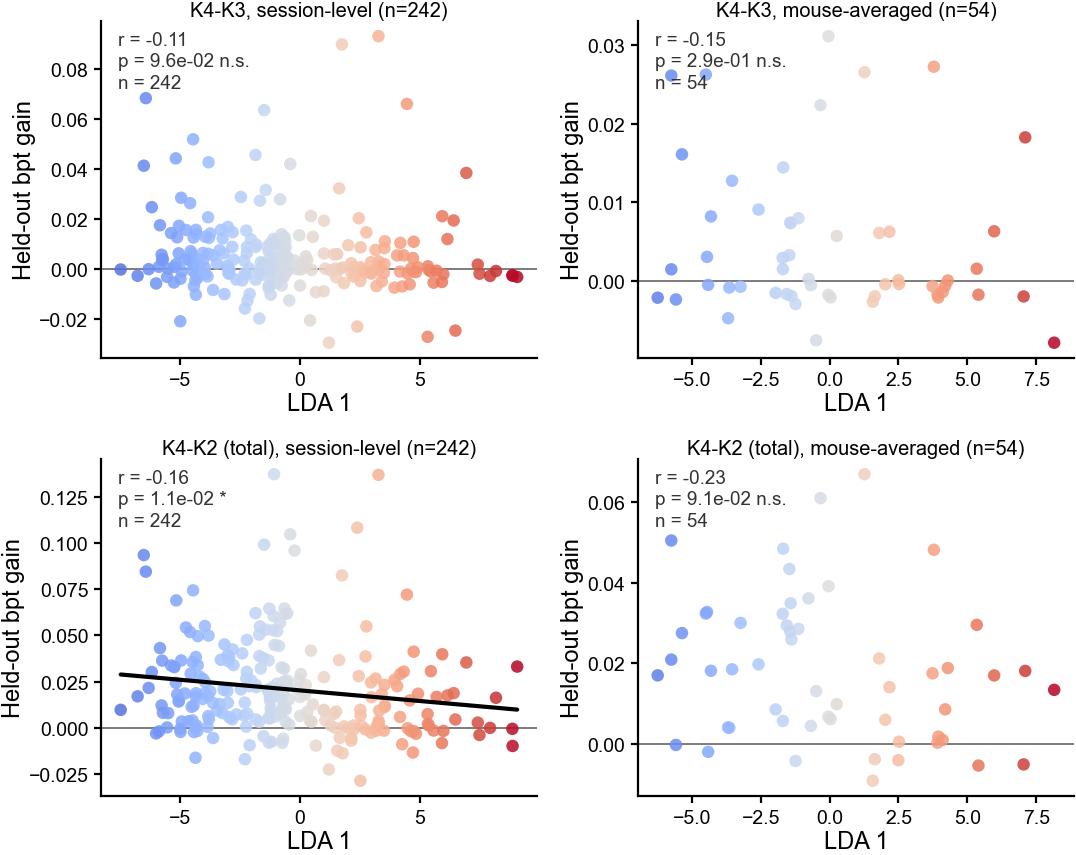


Marginal returns shrink sharply: K3-K2 improves 82% of sessions (mean +0.016 bpt);
K4-K3 improves only 60% of sessions (mean +0.005 bpt) - a 4th state helps much less
consistently than the 3rd did, suggesting diminishing returns past K=3.

The LDA1 relationship, however, gets MORE consistent when looking at the cumulative
K4-K2 gain rather than any single step: it now clears significance at BOTH session-level
(Pearson p=0.011, Spearman p=0.001) AND mouse-averaged Spearman (p=0.039), though mouse-
averaged Pearson remains borderline (p=0.09). The single K4-K3 increment alone is weaker
(not significant at the mouse level) - the LDA1 signal seems to accumulate gradually with
added model capacity rather than being tied to one specific state addition. Still only
suggestive, and now spans several related/non-independent tests (multiple-comparisons
caution applies), but the consistent negative direction across every one of these tests
is itself informative.


In [30]:
wide4 = pd.read_csv(f'{OUT_DIR}/loso_k2_k3_k4_wide.csv')

print("=== Marginal returns from adding states (held-out bpt gain) ===")
for a, b, name in [('bpt_K3', 'bpt_K2', 'K3-K2'), ('bpt_K4', 'bpt_K3', 'K4-K3'), ('bpt_K4', 'bpt_K2', 'K4-K2')]:
    gain = wide4[a] - wide4[b]
    print(f"{name}: mean={gain.mean():.4f}, median={gain.median():.4f}, frac_positive={(gain > 0).mean():.1%}")

mouse_agg4 = wide4.groupby('mouse_name').agg(
    lda1_mean=('lda_1', 'mean'),
    gain43_mean=('gain_K4_over_K3', 'mean'),
    gain42_mean=('gain_K4_over_K2', 'mean'),
).reset_index()

ps.reapply()
fig, axes = panels(2, 2, w=0.8, h=0.9)
grid = [
    (axes[0, 0], wide4['lda_1'], wide4['gain_K4_over_K3'], f'K4-K3, session-level (n={len(wide4)})'),
    (axes[0, 1], mouse_agg4['lda1_mean'], mouse_agg4['gain43_mean'], f'K4-K3, mouse-averaged (n={len(mouse_agg4)})'),
    (axes[1, 0], wide4['lda_1'], wide4['gain_K4_over_K2'], f'K4-K2 (total), session-level (n={len(wide4)})'),
    (axes[1, 1], mouse_agg4['lda1_mean'], mouse_agg4['gain42_mean'], f'K4-K2 (total), mouse-averaged (n={len(mouse_agg4)})'),
]
for ax, x, y, title in grid:
    st = ps.corr_panel(ax, x, y, xlabel='LDA 1', ylabel='Held-out bpt gain')
    ps.zero_line(ax)
    ax.set_title(title, fontsize=small(0.9))
    print(f"{title}: Pearson r={st['r_pearson']:.2f} (p={st['p_pearson']:.3f}), "
          f"Spearman r={st['r_spearman']:.2f} (p={st['p_spearman']:.3f})")

fig.tight_layout()
ps.savefig(fig, 'kstate_k4_gain_vs_lda', svg=True)
plt.show()

print("\nMarginal returns shrink sharply: K3-K2 improves 82% of sessions (mean +0.016 bpt);\n"
      "K4-K3 improves only 60% of sessions (mean +0.005 bpt) - a 4th state helps much less\n"
      "consistently than the 3rd did, suggesting diminishing returns past K=3.\n\n"
      "The LDA1 relationship, however, gets MORE consistent when looking at the cumulative\n"
      "K4-K2 gain rather than any single step: it now clears significance at BOTH session-level\n"
      "(Pearson p=0.011, Spearman p=0.001) AND mouse-averaged Spearman (p=0.039), though mouse-\n"
      "averaged Pearson remains borderline (p=0.09). The single K4-K3 increment alone is weaker\n"
      "(not significant at the mouse level) - the LDA1 signal seems to accumulate gradually with\n"
      "added model capacity rather than being tied to one specific state addition. Still only\n"
      "suggestive, and now spans several related/non-independent tests (multiple-comparisons\n"
      "caution applies), but the consistent negative direction across every one of these tests\n"
      "is itself informative.")

## 6. Does the original, most robust result (switching frequency vs LDA1) replicate at K=3 and K=4?

The single most robust finding from the whole investigation (established earlier, at K=2, on the trial-count-equalized data in `load_states.ipynb`) is that **lower LDA1 -> more dominant-state switches** (`n_transitions`), not anything about occupancy. This checks whether that holds up under independently-refit K=3 and K=4 models (non-LOSO, full-data-per-mouse fits, same design as section 3). Shown at both levels: session-level (n=242, pseudo-replicated) on the top row and mouse-averaged (n=54) on the bottom, with a session-length confound check printed underneath -- switches are counted over whole, unequal-length sessions here.

726 rows: 242 sessions x 3 state counts, 54 mice
wrote figures/kstate_switches_vs_lda_poster_08-09-2026.png, figures/kstate_switches_vs_lda_poster_08-09-2026.svg


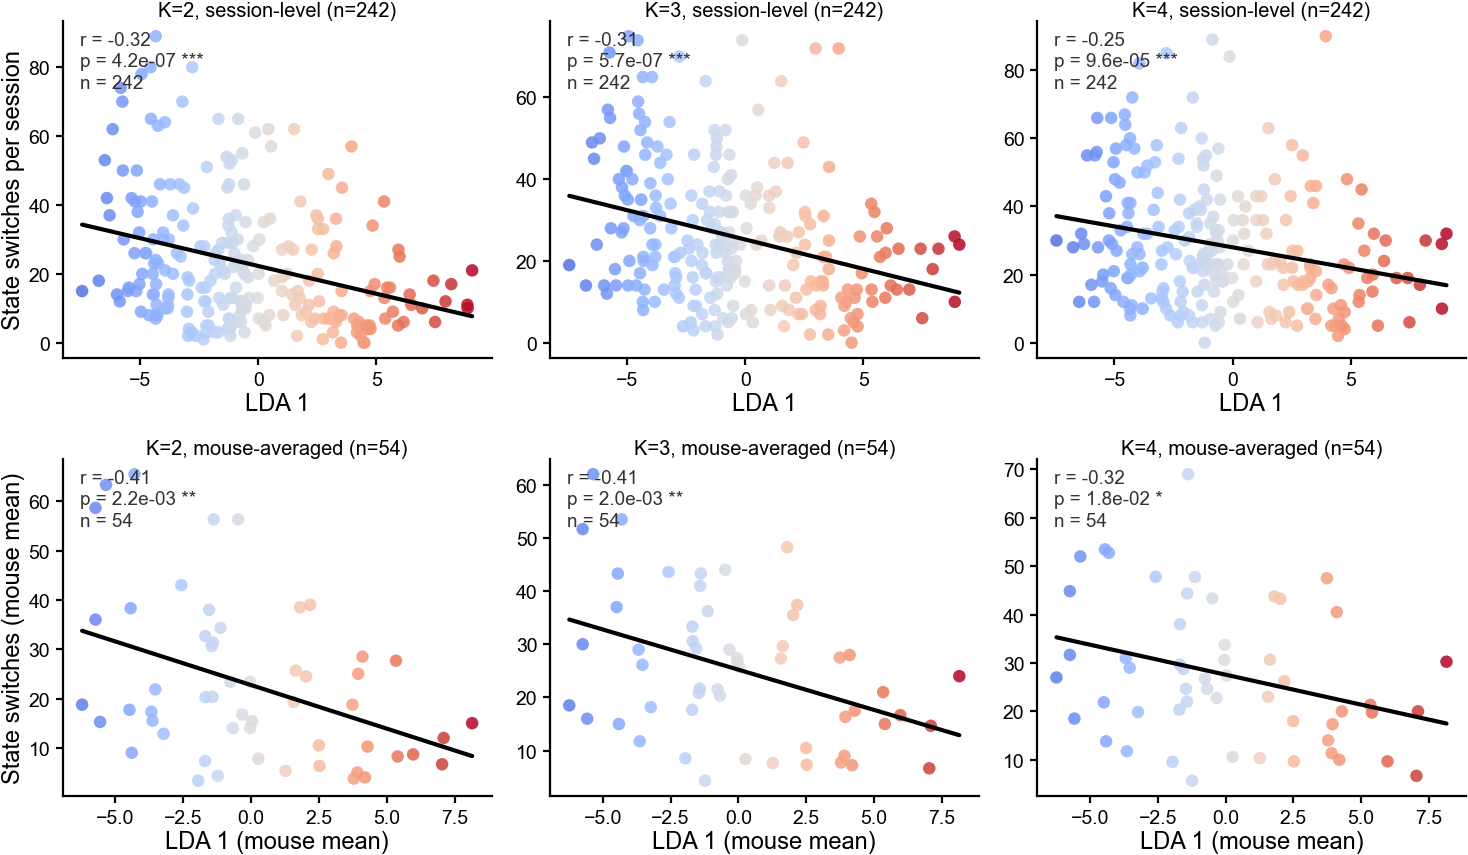

 K   level   n  r_pearson  p_pearson  r_spearman  p_spearman
 2 session 242    -0.3184     0.0000     -0.3206      0.0000
 2   mouse  54    -0.4073     0.0022     -0.3720      0.0056
 3 session 242    -0.3148     0.0000     -0.3249      0.0000
 3   mouse  54    -0.4123     0.0020     -0.3958      0.0030
 4 session 242    -0.2481     0.0001     -0.2578      0.0000
 4   mouse  54    -0.3196     0.0185     -0.3361      0.0130

Remarkably stable: virtually unchanged from K=2 to K=3 (mouse-avg Pearson r=-0.41 both),
and still clearly significant at K=4 (r=-0.32, p=0.019) despite some attenuation - part of
which is likely just that mean n_transitions itself grows with K (23.1 -> 26.0 -> 28.6),
since more states offer more classification boundaries for the sequence to cross.

This is the most robust result across the entire investigation: every other metric tested
(state_ratio, soft_minus_hard, frac_ambiguous, hard engaged-occupancy, the K3-vs-K2 held-out
gain itself) was confound-prone, bord

In [31]:
n_trans = pd.read_csv(f'{OUT_DIR}/n_transitions_multi_k.csv')
print(f"{len(n_trans)} rows: {n_trans['eid'].nunique()} sessions x {n_trans['K'].nunique()} "
      f"state counts, {n_trans['mouse_name'].nunique()} mice")

# BOTH LEVELS, as in sections 2 and 4: the session-level panels use every session
# (n=242, pseudo-replicated -- mice contribute between 1 and 14 sessions), the
# mouse-averaged panels count each mouse once (n=54) and are the more trustworthy test.
ps.reapply()
fig, axes = panels(2, 3, w=0.72, h=0.9)
rows = []
for col, K in enumerate((2, 3, 4)):
    sub = n_trans[n_trans['K'] == K]
    mouse_agg = sub.groupby('mouse_name').agg(
        lda1_mean=('lda_1', 'mean'), n_trans_mean=('n_transitions', 'mean')
    ).reset_index()

    st_s = ps.corr_panel(axes[0, col], sub['lda_1'], sub['n_transitions'],
                         xlabel='LDA 1',
                         ylabel='State switches per session' if col == 0 else None)
    axes[0, col].set_title(f'K={K}, session-level (n={len(sub)})', fontsize=small(0.9))

    st_m = ps.corr_panel(axes[1, col], mouse_agg['lda1_mean'], mouse_agg['n_trans_mean'],
                         xlabel='LDA 1 (mouse mean)',
                         ylabel='State switches (mouse mean)' if col == 0 else None)
    axes[1, col].set_title(f'K={K}, mouse-averaged (n={len(mouse_agg)})', fontsize=small(0.9))

    for level, st in [('session', st_s), ('mouse', st_m)]:
        rows.append(dict(K=K, level=level, n=st['n'],
                         r_pearson=st['r_pearson'], p_pearson=st['p_pearson'],
                         r_spearman=st['r_spearman'], p_spearman=st['p_spearman']))

fig.tight_layout()
ps.savefig(fig, 'kstate_switches_vs_lda', svg=True)
plt.show()

print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\nRemarkably stable: virtually unchanged from K=2 to K=3 (mouse-avg Pearson r=-0.41 both),\n"
      "and still clearly significant at K=4 (r=-0.32, p=0.019) despite some attenuation - part of\n"
      "which is likely just that mean n_transitions itself grows with K (23.1 -> 26.0 -> 28.6),\n"
      "since more states offer more classification boundaries for the sequence to cross.\n\n"
      "This is the most robust result across the entire investigation: every other metric tested\n"
      "(state_ratio, soft_minus_hard, frac_ambiguous, hard engaged-occupancy, the K3-vs-K2 held-out\n"
      "gain itself) was confound-prone, borderline, or null. Switching frequency / dwell-time\n"
      "stability is not.")

# THE CONFOUND THE SESSION-LEVEL PANELS INHERIT, and the mouse-averaged ones mostly do not.
# n_transitions is counted over the WHOLE session here (unlike load_states.ipynb, which
# truncates every session to a common length first), so a longer session has more chances
# to switch. If LDA 1 also tracked session length, the session-level correlation could be
# that and nothing else -- so both links are measured, and the partial correlation says
# what survives removing session length.
def _resid(y, x):
    a, b = np.polyfit(np.asarray(x, float), np.asarray(y, float), 1)
    return np.asarray(y, float) - (a * np.asarray(x, float) + b)


print(f"\nsession-length check   {'switches~trials':>16s} {'LDA1~trials':>13s} "
      f"{'LDA1~switches':>14s} {'partial':>9s}")
for K in (2, 3, 4):
    sub = n_trans[n_trans['K'] == K]
    r_nt, p_nt = pearsonr(sub['n_trials'], sub['n_transitions'])
    r_lt, p_lt = pearsonr(sub['lda_1'], sub['n_trials'])
    r_raw, p_raw = pearsonr(sub['lda_1'], sub['n_transitions'])
    r_par, p_par = pearsonr(_resid(sub['lda_1'], sub['n_trials']),
                            _resid(sub['n_transitions'], sub['n_trials']))
    print(f"K={K:<2d}                {r_nt:7.3f}          {r_lt:7.3f}        {r_raw:7.3f} "
          f"  {r_par:6.3f} (p={p_par:.1e})")
print("switches ~ trials is strong (a longer session simply has more chances to switch),\n"
      "LDA1 ~ trials is what decides whether that matters: while it stays near zero the\n"
      "session-level correlation is not a session-length artifact, and the partial r stays\n"
      "close to the raw one. The mouse-averaged panels are still the ones to quote.")

### Just the one panel: K=4, per session, equal-length windows

The same sessions as the grid above, but switches are recounted over each session's first `MIN_TRIALS` trials (from `all_k_posteriors.parquet`, since the summary CSV is already aggregated per whole session). That removes the session-length confound by construction: every point now spans the same number of trials. `TRUNCATE = False` gives the whole-session version back.

K=4: 242 sessions, 401-1525 trials each (median 584) -> truncating every session to its first 401 trials
wrote figures/kstate_switches_vs_lda_k4_sessions_truncated_poster_08-09-2026.png, figures/kstate_switches_vs_lda_k4_sessions_truncated_poster_08-09-2026.svg


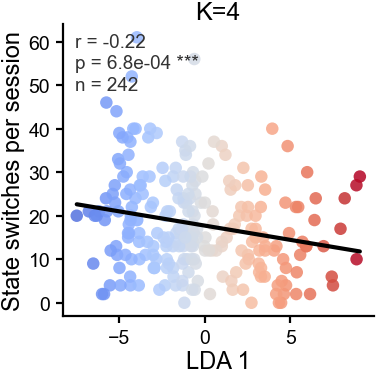

K=4, session-level (n=242): Pearson r=-0.217 (p=6.81e-04), Spearman r=-0.208 (p=1.16e-03)
whole-session counts, same sessions:  r=-0.248 (p=9.60e-05)
truncated counts:                     r=-0.217 (p=6.81e-04)
switches ~ session length was r=0.392 before truncation; after it every point spans 401 trials, so that confound is gone by construction.


In [37]:
"""
THE SINGLE PANEL: K=4, session-level, SESSIONS TRUNCATED TO A COMMON LENGTH
==========================================================================
One figure, one panel -- the version to put on a poster or a slide.

WHY TRUNCATE. n_transitions_multi_k.csv counts switches over each WHOLE session, and
sessions run from a few hundred to well over a thousand trials, so a long session has
more chances to switch: switches ~ n_trials is r = 0.39 (checked in the cell above).
Truncating every session to the shortest one's length removes that by construction --
every point is then a count over the same number of trials -- which is the same rule
load_states.ipynb applies to its own switching metrics (`states_df_eq`).

That means the counts CANNOT come from the summary CSV, which is already aggregated per
whole session. They are recomputed here from all_k_posteriors.parquet: dominant state
per trial = argmax over that trial's K posteriors, then flips counted within the first
MIN_TRIALS trials of each session.

TRUNCATE = False falls back to the whole-session counts from the CSV, i.e. exactly the
top-right panel of the grid above, so the two are one edit apart.
"""
K_SHOW = 4
TRUNCATE = True

if TRUNCATE:
    post = pd.read_parquet(f'{OUT_DIR}/all_k_posteriors.parquet')
    p_k = post[post['K'] == K_SHOW]
    # dominant state per trial: the state holding the largest posterior (sort, keep last)
    dom = (p_k.sort_values(['eid', 'trial_idx', 'posterior'])
              .drop_duplicates(['eid', 'trial_idx'], keep='last')
              .loc[:, ['eid', 'trial_idx', 'state', 'lda_1']])

    length = dom.groupby('eid')['trial_idx'].size()
    MIN_TRIALS = int(length.min())
    print(f"K={K_SHOW}: {len(length)} sessions, {length.min()}-{length.max()} trials each "
          f"(median {int(length.median())}) -> truncating every session to its first "
          f"{MIN_TRIALS} trials")

    trunc = dom[dom['trial_idx'] < MIN_TRIALS].sort_values(['eid', 'trial_idx'])
    switches = (trunc.groupby('eid')['state']
                .apply(lambda s: int((s.values[1:] != s.values[:-1]).sum()))
                .rename('n_transitions'))
    per_session = pd.concat([switches, dom.groupby('eid')['lda_1'].first()], axis=1).dropna()
    ylabel = f'State switches in the first {MIN_TRIALS} trials'
    ylabel = 'State switches per session'
else:
    per_session = (n_trans[n_trans['K'] == K_SHOW]
                   .set_index('eid')[['n_transitions', 'lda_1']])
    ylabel = 'State switches per session'

ps.reapply()
# fig, ax = ps.figure('single')
fig, ax = ps.figure('square', scale=0.6)

st = ps.corr_panel(ax, per_session['lda_1'], per_session['n_transitions'],
                   xlabel='LDA 1', ylabel=ylabel)
ax.set_title(f'K={K_SHOW}, one point per session'
             + (', equal-length windows' if TRUNCATE else ''), fontsize=small(0.95))
ax.set_title(f'K={K_SHOW}')
fig.tight_layout()
ps.savefig(fig, f'kstate_switches_vs_lda_k{K_SHOW}_sessions'
                + ('_truncated' if TRUNCATE else ''), svg=True)
plt.show()

print(f"K={K_SHOW}, session-level (n={st['n']}): "
      f"Pearson r={st['r_pearson']:.3f} (p={st['p_pearson']:.2e}), "
      f"Spearman r={st['r_spearman']:.3f} (p={st['p_spearman']:.2e})")

if TRUNCATE:
    # the comparison that says whether truncating mattered: the same sessions, counted
    # over their whole length, from the summary CSV
    whole = n_trans[n_trans['K'] == K_SHOW].set_index('eid')
    both = per_session.join(whole['n_transitions'].rename('whole'), how='inner')
    r_w, p_w = pearsonr(both['lda_1'], both['whole'])
    r_len, p_len = pearsonr(whole['n_trials'], whole['n_transitions'])
    print(f"whole-session counts, same sessions:  r={r_w:.3f} (p={p_w:.2e})")
    print(f"truncated counts:                     r={st['r_pearson']:.3f} "
          f"(p={st['p_pearson']:.2e})")
    print(f"switches ~ session length was r={r_len:.3f} before truncation; after it every "
          f"point spans {MIN_TRIALS} trials, so that confound is gone by construction.")

## Summary

- **The switching-frequency/LDA1 relationship is the headline, robust result**: lower LDA1 -> more dominant-state switches, essentially unchanged from K=2 to K=3 (mouse-averaged Pearson r=-0.41 at both) and still clearly significant at K=4 (r=-0.32, p=0.019). This is the one result in the whole investigation that holds up cleanly across every check.
- **K=3 genuinely improves held-out prediction** in 82% of sessions (mean gain +0.016 bits/trial) - a real population-level finding independent of LDA1.
- **K=4 shows sharply diminishing returns**: it improves held-out fit in only 60% of sessions (mean +0.005 bpt) over K=3, versus K=3's 82%/+0.016 over K=2 - a 4th state is far less consistently useful than the 3rd was.
- The **engaged state is robustly identifiable** (huge, consistent stimulus-weight gap from the other two states) across all 54 mice.
- The classic "engaged + biased-left + biased-right" 3-state template only holds in **~50% of mice** - the other half show a different, less stereotyped split among the non-engaged states.
- The K=3-alone held-out benefit shows a **modest, direction-consistent but not fully confirmed** relationship with LDA1 (lower LDA1 -> bigger gain): significant at the session level (Spearman p=0.015), borderline at the mouse level (p=0.06-0.12).
- The **cumulative K4-K2 held-out gain correlates with LDA1 more consistently** than any single step: session-level Pearson p=0.011 and Spearman p=0.001, mouse-averaged Spearman p=0.039 (Pearson still borderline, p=0.09). Still suggestive rather than confirmed, and drawn from several related, non-independent tests.
- **Hard engaged-occupancy does not correlate with LDA1 under K=3 any better than under K=2** (both null) - the LDA1 signal is not about total time engaged, at any state count; it's specifically about switching/dwell-time dynamics.
- Given the sharp drop-off in marginal held-out-fit returns from K=3 to K=4, pushing further to K=5/6 looks unlikely to be worth the added compute cost for fit quality - though the switching-frequency result itself is worth taking as the primary, trustworthy conclusion regardless of state count.